In [1]:
from preprocess import load_data, rename_columns, create_binary_label, first_failure_filter, engineer_features
import math
import matplotlib.pyplot as plt
import seaborn as sns

df = load_data("data/american_bankruptcy.csv")
df = rename_columns(df)
df = create_binary_label(df)
df = first_failure_filter(df)
df = engineer_features(df)

/Users/phucdang/Documents/personal projects/warn-pred-bankr/preprocess.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("company_name", group_keys = False).apply(keep_until_failure)


In [2]:
df.shape

(74071, 29)

In [3]:
df.head()

,company_name,status_label,year,current_assets,cost_of_goods_sold,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,total_liabilities,operating_expenses,net_profit_margin,gross_profit_margin,roa,ros,current_ratio,quick_ratio,debt_to_asset_ratio,asset_turnover
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,401.483,935.302,0.034328,0.186683,0.047454,0.034328,3.120983,1.069792,0.541814,1.382369
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,361.642,809.888,0.021196,0.183521,0.026403,0.021196,3.874697,1.317995,0.515267,1.245637
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,399.964,611.514,-0.092277,0.175732,-0.082989,-0.092277,2.902063,0.997368,0.563172,0.899355
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,391.633,575.592,-0.020467,0.180741,-0.018074,-0.020467,1.947253,0.670308,0.570377,0.883074
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,407.608,604.467,0.005375,0.197338,0.004940,0.005375,3.292707,1.409093,0.574669,0.919167


In [4]:
df["status_label"].value_counts(normalize = True)

status_label
0    0.991778
1    0.008222
Name: proportion, dtype: float64

In [5]:
df.groupby("status_label")["company_name"].nunique()

status_label
0    8362
1     609
Name: company_name, dtype: int64

In [6]:
df.drop(columns=["year"]).describe().T

,count,mean,std,min,25%,50%,75%,max
status_label,74071.0,0.008222,0.090301,0.000000,0.000000,0.000000,0.000000,1.000000e+00
current_assets,74071.0,909.341816,4036.716712,-7.760000,19.163500,102.246000,447.069500,1.696620e+05
cost_of_goods_sold,74071.0,1638.833119,9176.207013,-366.645000,16.923500,103.151000,647.414500,3.746230e+05
depreciation_amortization,74071.0,123.126650,668.795693,0.000000,1.180000,7.888000,47.803500,2.843000e+04
ebitda,74071.0,391.193587,2068.484955,-21913.000000,-0.673000,15.525000,143.500000,8.173000e+04
inventory,74071.0,207.456557,1085.984240,0.000000,0.000000,7.075000,76.194500,6.256700e+04
net_income,74071.0,140.879525,1294.114531,-98696.000000,-6.526000,2.036000,43.003500,1.048210e+05
total_receivables,74071.0,296.163709,1372.360962,-0.006000,3.346000,23.272000,135.153500,6.581200e+04
market_cap,74071.0,3574.042875,18953.473877,0.000100,35.876300,239.294000,1309.235200,1.073391e+06
net_sales,74071.0,2434.930617,12279.844848,-1964.999000,27.572000,186.095000,1074.291000,5.117290e+05


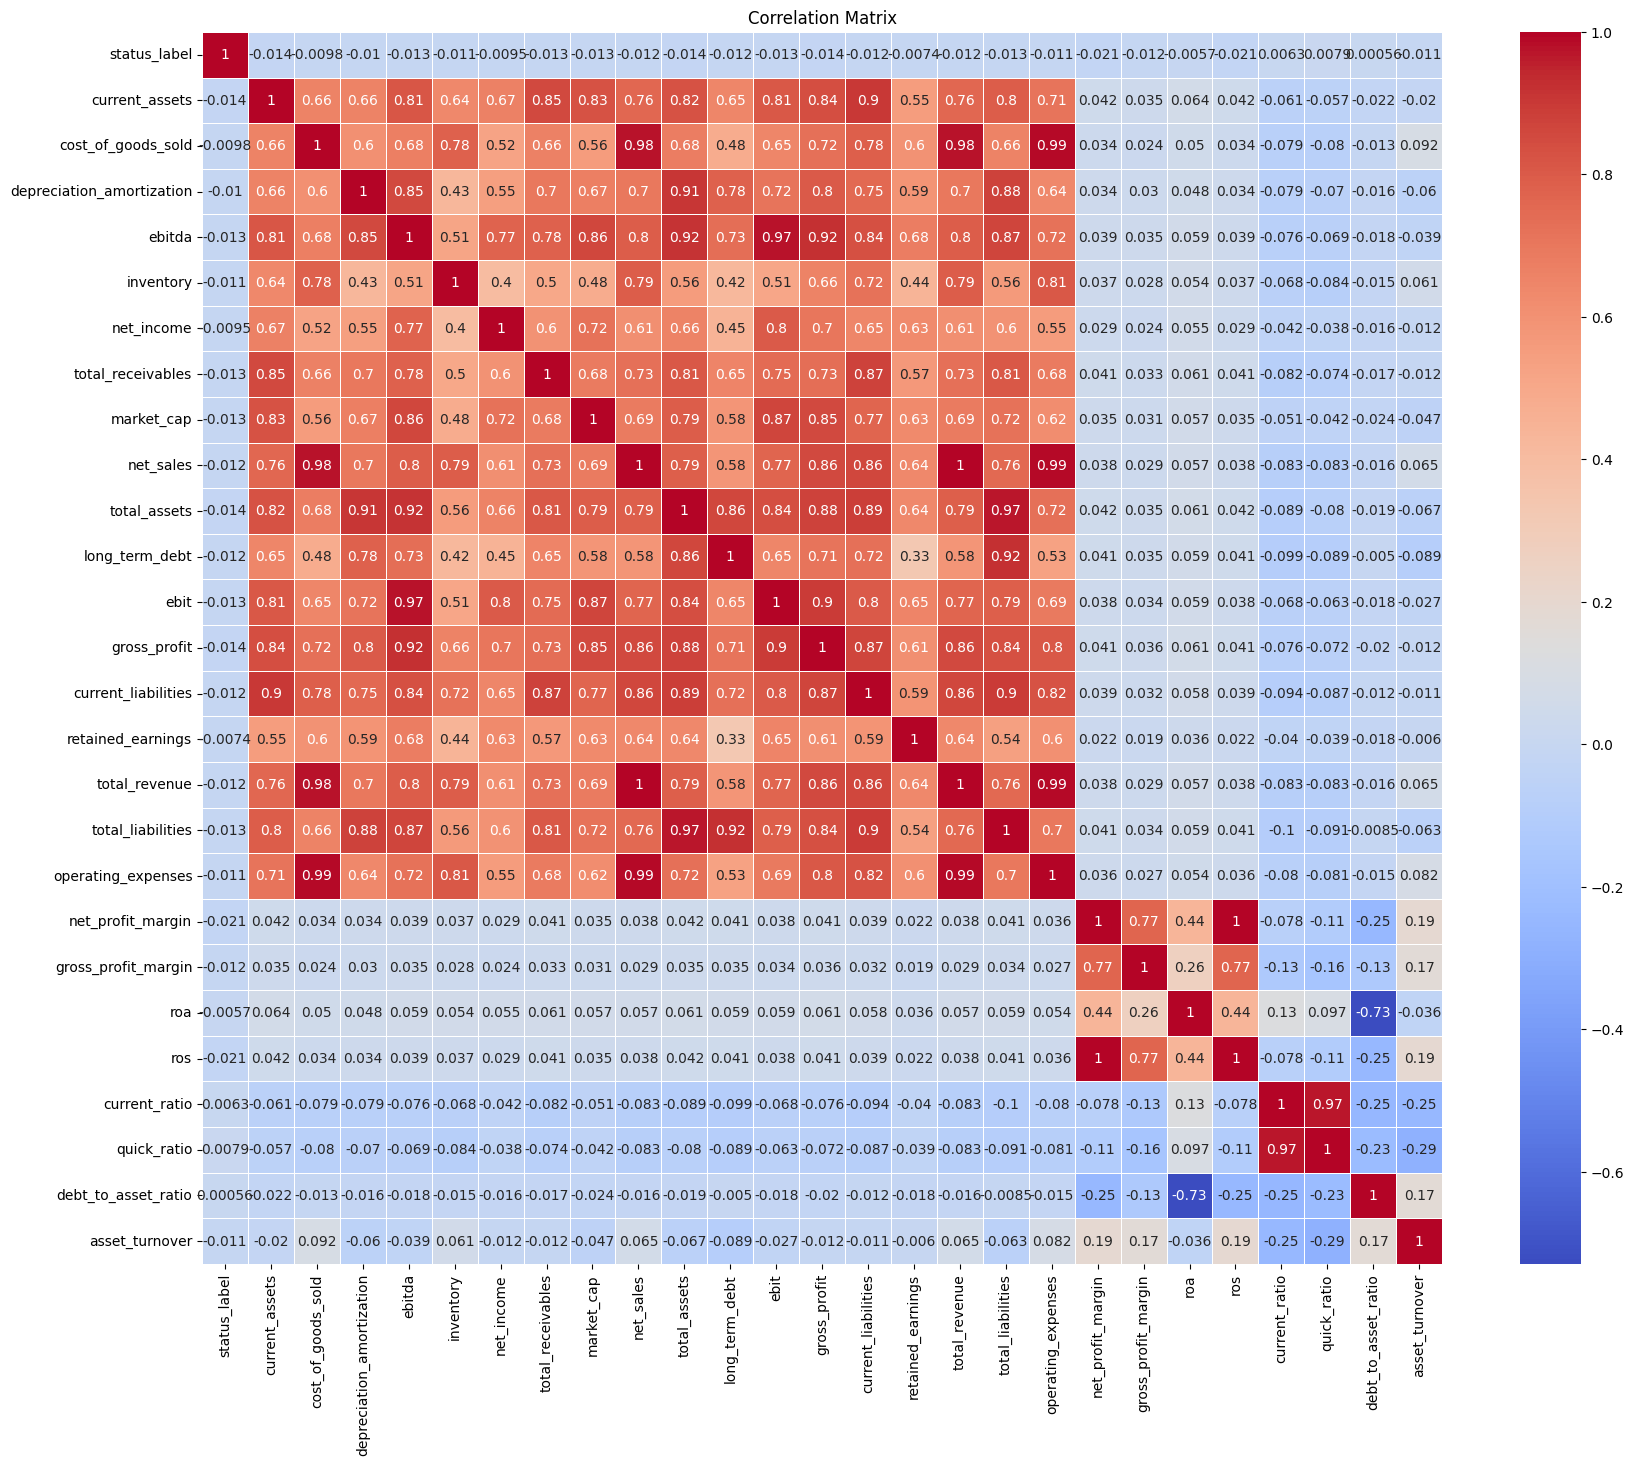

In [7]:
df_numeric = df.select_dtypes(include=["number"]).drop(columns=["year"])

plt.figure(figsize=(20, 16))
corr = df_numeric.corr()
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,
            cmap="coolwarm", annot=True, linewidth=0.5)

plt.title("Correlation Matrix")
plt.show()

In [8]:
df_numeric = df.select_dtypes(include=["number"])
df_means = df_numeric.groupby("year").mean()

n_features = len(df_means.columns)
n_cols = 5
n_rows = math.ceil(n_features / n_cols)

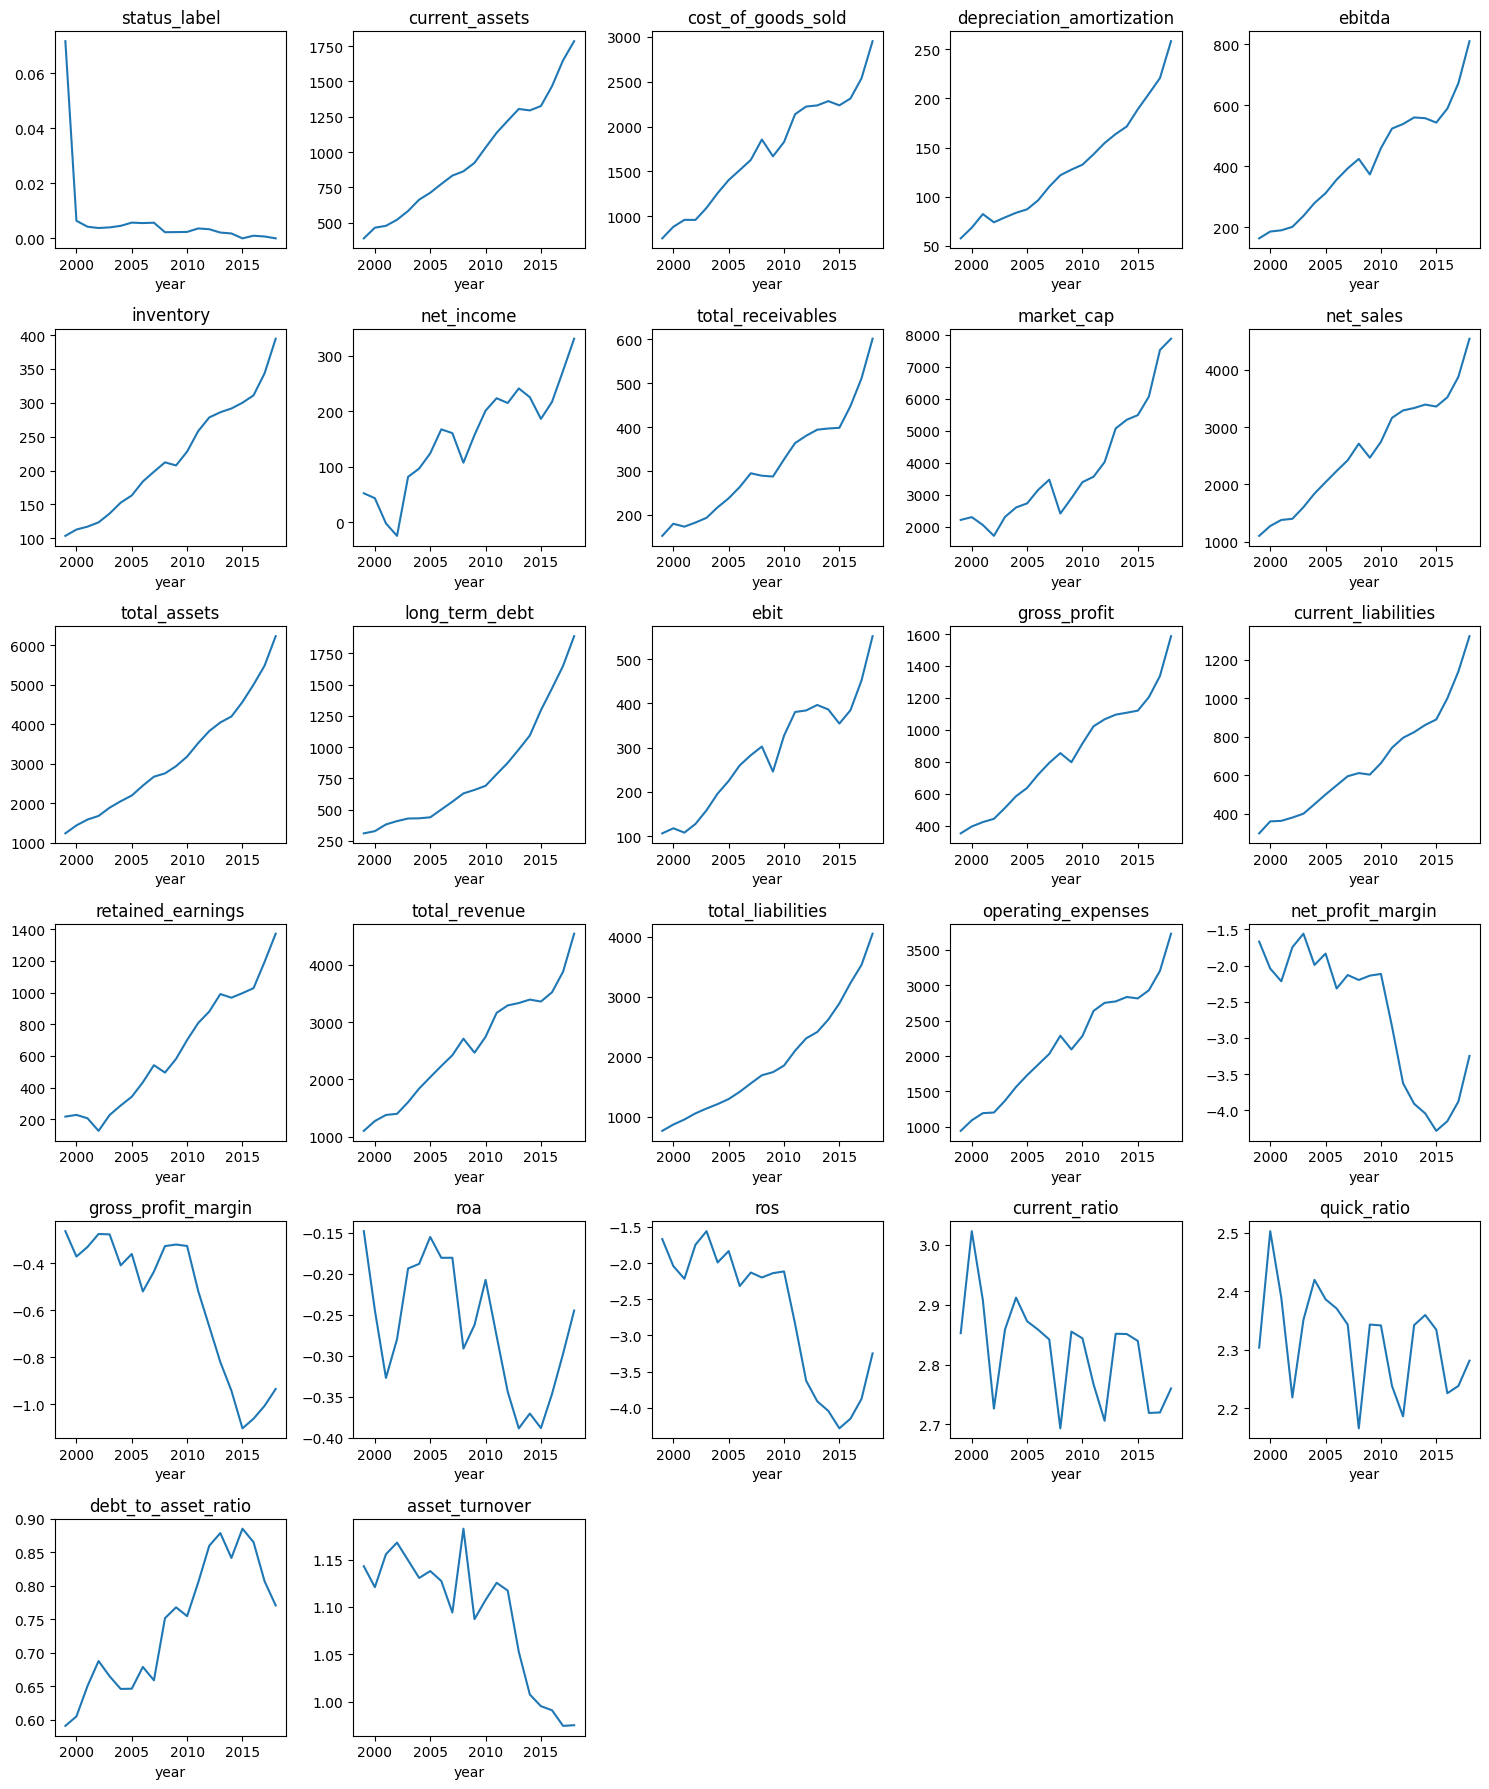

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()

for i, feature_name in enumerate(df_means.columns):
    df_means[feature_name].plot(kind="line", ax=axes[i])
    axes[i].set_title(feature_name)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

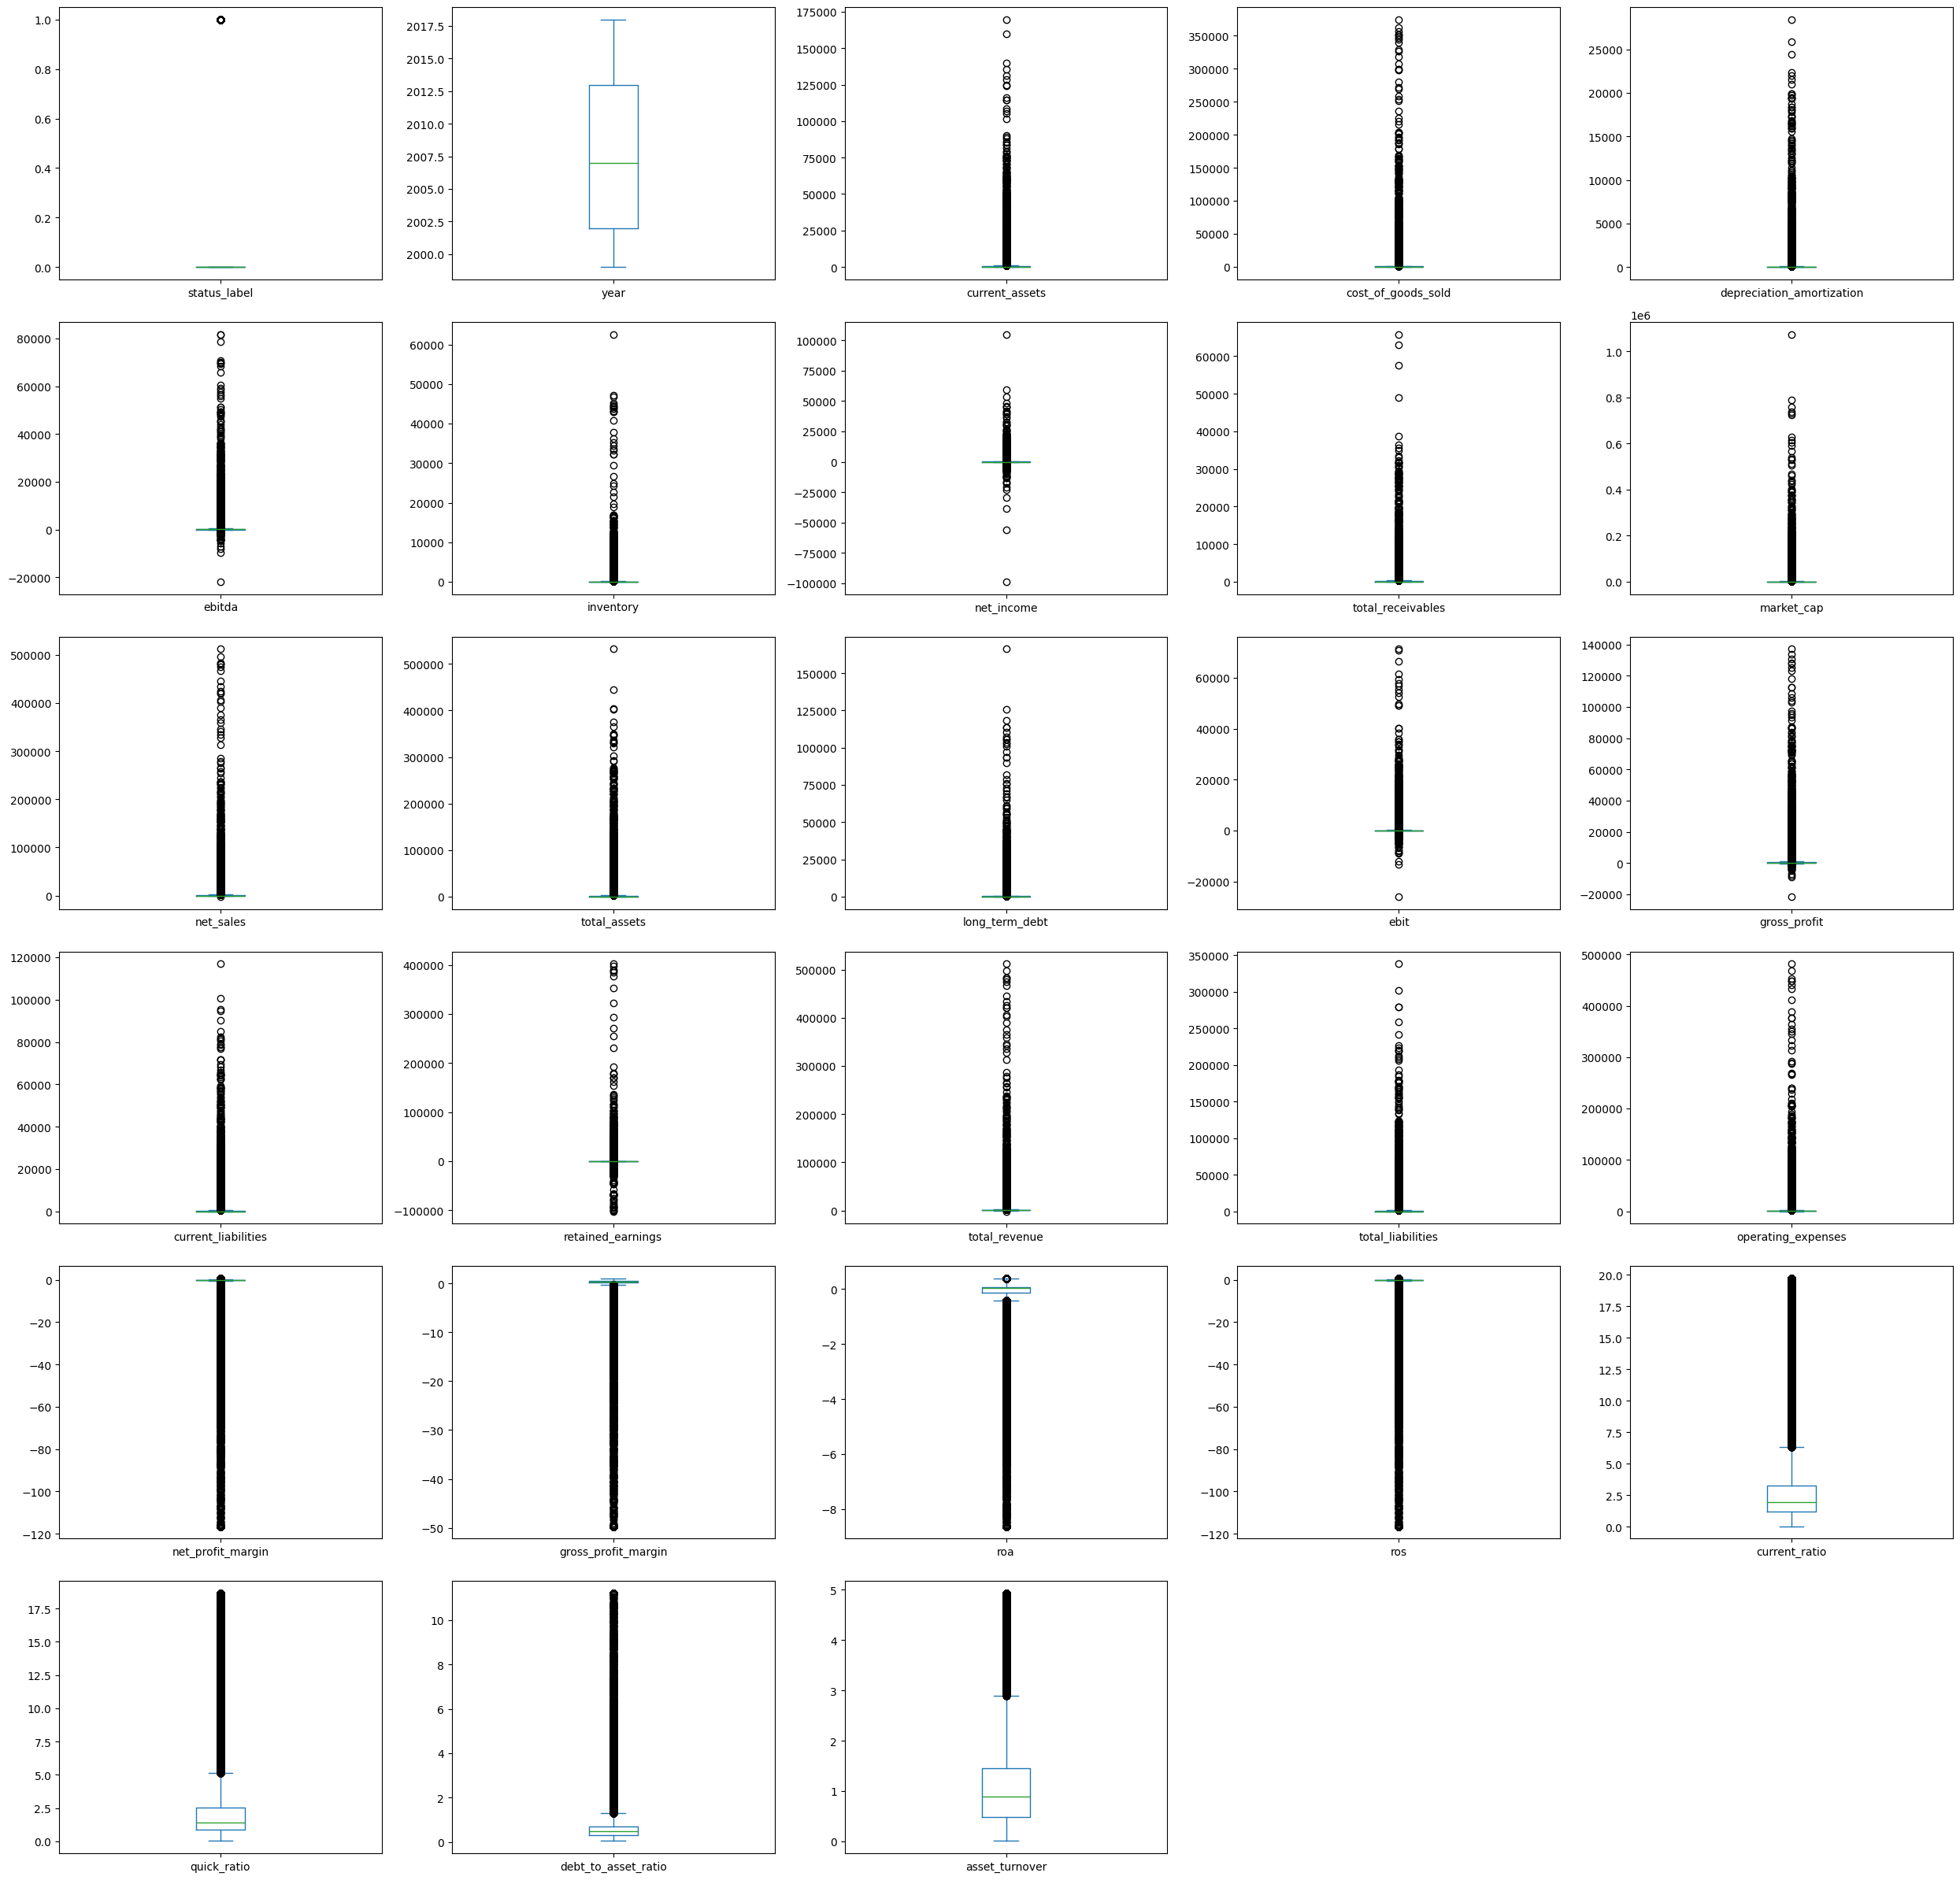

In [10]:
df_numeric.plot(kind="box", subplots=True, layout=(n_rows, n_cols),
                figsize=(n_cols * 5, n_rows * 4), sharex=False,)
plt.tight_layout()
plt.show()